In [1]:
# Import the FEMSystem Class from directory above
import sys
from VisualizeVF import VisualizeVF
sys.path.append('..')
from FEMSystem import FEMSystem

import jax.numpy as jnp
import pickle
import matplotlib.pyplot as plt
import numpy as np
from Units2D import Units2D

In [15]:
from scipy.sparse.linalg import spsolve
from skfem import  ElementTriN1, ElementTriP1, Basis, BilinearForm, LinearForm, asm, condense, ElementVector
from skfem.helpers import curl, dot
import numpy as np
from FEMSystem import FEMSystem
import jax.numpy as jnp
import pickle
from scipy.linalg import expm
from tqdm.auto import tqdm

class RabiLondon2D:
    
    # Statics Solution
    femsystem:FEMSystem = None
    mesh = None
    u_left:jnp.ndarray = None
    u_right:jnp.ndarray = None
    u_even:jnp.ndarray = None
    u_odd:jnp.ndarray = None
    u_even_interior:jnp.ndarray = None
    u_odd_interior:jnp.ndarray = None
    theta_at_dofs:jnp.ndarray = None
    n:jnp.ndarray = None # Dimension of coefficients vector
    N:int = None # Total number of bosons
    coeffs:jnp.ndarray = None
    E_J:float = None
    E_C:float = None

    # Eigenvalues and Eigenvectors
    hamiltonian:jnp.ndarray = None
    eigenvectors:jnp.ndarray = None
    eigenvalues:jnp.ndarray = None
    charge_imbalance_eigenvalues:jnp.ndarray = None

    def __init__(self, pickled_obj):
        # Get Modes, Coefficients, and EJ/EC, and n/N + FEMSystem
        femsystem:FEMSystem = pickled_obj["femsystem"]
        femsystem.saveFigsDir = None # Turn OFF saving plots
        self.femsystem = femsystem
        self.mesh = femsystem.mesh
        self.u_even,self.u_odd = pickled_obj["u_even"],pickled_obj["u_odd"]
        self.u_left,self.u_right = 1/jnp.sqrt(2)*(self.u_even - self.u_odd), 1/jnp.sqrt(2)* (self.u_even + self.u_odd)
        self.u_even_interior,self.u_odd_interior = self.u_even[femsystem.interior_dofs],self.u_odd[femsystem.interior_dofs]
        self.n,self.N,self.coeffs = pickled_obj["n"],pickled_obj["parameters"]["N"],pickled_obj["coeffs"]
        self.E_J,self.E_C = pickled_obj["E_J"],pickled_obj["E_C"]
        self.integrated_area = pickled_obj["integrated_area"]
        self.area = pickled_obj["parameters"]["sidelenX"] * pickled_obj["parameters"]["sidelenY"] * 2

        print(f"---- Successfully initialed RabiLondon2D Object ----")
        print(f"Integrated Area: {self.integrated_area} | Area: {self.area} | Error: {abs(self.integrated_area - self.area)/self.integrated_area*100:.2f}%")
        print(f"EJ: {self.E_J} | EC: {self.E_C} | EJ/EC: {self.E_J/self.E_C}")

        # Now run eigensolver
        self.hamiltonian, self.eigenvectors, self.eigenvalues, self.charge_imbalance_eigenvalues = self.eigensolver()


        # Keep scalar as plain float for downstream scipy/skfem assembly code.
        self.omega_q = float(self.eigenvalues[1] - self.eigenvalues[0])
        print(f"Qubit Frequency: {self.omega_q} (non-dimensional energy units)")



    # Assume that half charge imbalance is perfectly centered around 0
    # So odd n: -1 0 1 in middle, even n: -0.5 0.5 in middle
    def eigensolver(self):
        # Construct charge imbalance Eigenvalues
        charge_imbalance_eigenvalues = (self.n-1)/2 - jnp.arange(self.n)

        # Construct Discrete Hamiltonian Matrix
        def Jz2(n):
            j = (n-1)/2
            diagonals = j - jnp.arange(n)
            return jnp.diag(diagonals**2)
        def off_diag(n,k):
            ones_super, ones_sub = jnp.ones(n - k, dtype=jnp.int32),jnp.ones(n - k, dtype=jnp.int32)
            super_diag_matrix,sub_diag_matrix= jnp.diag(ones_super, k=k),jnp.diag(ones_sub, k=-1*k)
            result = super_diag_matrix + sub_diag_matrix
            return result 
        def cos_phi(n):
            return off_diag(n,1) / 2
        hamiltonian = self.E_C * Jz2(self.n) - self.E_J * cos_phi(self.n) # No need for e_0 term, since we are only interested in eigenvectors

        # Find Eigenvalues and Eigenvectors
        eigenvalues,eigenvectors = jnp.linalg.eigh(hamiltonian)

        # Normalize eigenvectors
        eigenvectors = eigenvectors / jnp.sqrt(jnp.sum(jnp.abs(eigenvectors)**2, axis=0, keepdims=True))
        return hamiltonian, eigenvectors, eigenvalues, charge_imbalance_eigenvalues


    def helmholtz_solver(self,omega_d,c_bar,kappa,source_obj,epsilon=1e-4,eta_gauge=1e-2):
        # Coerce potential JAX scalars into plain floats before skfem/scipy usage.
        omega_d = float(omega_d)
        c_bar = float(c_bar)
        kappa = float(kappa)
        source_coord = source_obj["source_coord"]
        sigma = float(source_obj["sigma"])
        m = float(source_obj["m"])


        # Define Coefficients
        a_coeff = - (omega_d/c_bar)**2
        b_coeff = 1/(kappa**2) * float(self.area) / float(self.N)


        # Define Nedelic Basis
        nedelic_element = ElementTriN1()
        basis_edge = Basis(self.mesh, nedelic_element, intorder=self.femsystem.intorder)

        # Approximated Time-Indendent Charge Density, in Nodal Basis
        psi_exp = (self.u_left **2 + self.u_right**2) * self.N / 2 + epsilon

        # Define Bilinear Form
        @BilinearForm
        def bilinear_form(u,v,w):
            # Nedelec (H(curl)) does not support div(u) in skfem;
            # use a small positive mass regularization to suppress near-gauge wiggles.
            second_term_coeff = a_coeff + b_coeff * w['psi_exp'] + eta_gauge
            return curl(u) * curl(v) + second_term_coeff * dot(u, v)

        # Define Linear Form, the Divergence-Free Dipole Source
        @LinearForm
        def dipole_source(v, w):
            x = w.x[0]
            y = w.x[1]
            x0, y0 = source_coord
            M = (m / (np.pi * sigma**2)) * np.exp(-((x - x0)**2 + (y - y0)**2) / sigma**2)
            Jx = -M * 2 * (y - y0) / sigma**2
            Jy =  M * 2 * (x - x0) / sigma**2
            J_vec = np.array([Jx, Jy])
            return dot(J_vec, v)

        # Assemble Matrices
        A_matrix = asm(bilinear_form, basis_edge,
                    psi_exp=self.femsystem.basis.interpolate(np.asarray(psi_exp, dtype=np.float64)))      
        b_vector = asm(dipole_source, basis_edge)
        # Apply Boundary Conditions
        A_sol = np.zeros(basis_edge.N)
        D = basis_edge.get_dofs().all()
        A_int, b_int, x_int, I = condense(A_matrix, b_vector, D=D)

        # Solve 
        A_sol[I] = spsolve(A_int, b_int)
        return A_sol, basis_edge



        # Delta function Source, comment this out for Gaussian Source
        # @LinearForm
        # def general_source(v, w):
        #     b_vec = np.array([w['bx'], w['by']])
        #     return dot(b_vec, v)
        # Search closest dof in basis_nodal.doflocs and size b_* with basis_nodal.N so interpolate() agrees.
        # source_coord = (0.0, 30.0)
        # source_coord_arr = np.array(source_coord).reshape(2, 1)
        # dof_xy = basis_nodal.doflocs
        # closest_node_index = int(np.argmin(np.sum((dof_xy - source_coord_arr) ** 2, axis=0)))
        # b_nodal_values = np.zeros((2, basis_nodal.N))
        # b_nodal_values[1, closest_node_index] = 1.0
        # b_vector = asm(general_source, basis_edge,
        #                bx=basis_nodal.interpolate(b_nodal_values[0,:]),
        #                by=basis_nodal.interpolate(b_nodal_values[1,:]))
    
    def _project_nedelec_to_vector_p1(self,femsystem, basis_edge, A_sol: np.ndarray):
        """L² project Nédélec A onto vector P1 (same mesh and quadrature order as modes)."""
        nodal_element = femsystem.element
        basis_vec_p1 = Basis(
            self.mesh, ElementVector(nodal_element), intorder=femsystem.intorder
        )

        @BilinearForm
        def mass_vec(u, v, w):
            return dot(u, v)

        @LinearForm
        def rhs_proj(v, w):
            return dot(w["A"], v)

        A_disc = basis_edge.interpolate(np.asarray(A_sol, dtype=np.float64))
        M = asm(mass_vec, basis_vec_p1)
        rhs = asm(rhs_proj, basis_vec_p1, A=A_disc)
        coeffs = spsolve(M, rhs)
        A_p1_disc = basis_vec_p1.interpolate(coeffs)
        val = np.asarray(A_p1_disc.value)
        Ax = jnp.asarray(val[0])
        Ay = jnp.asarray(val[1])
        divA = jnp.asarray(div(A_p1_disc))
        a2 = Ax * Ax + Ay * Ay
        return Ax, Ay, divA, a2

    def _epsilon_four_terms(self,femsystem,basis_edge,A_sol,phi_i,phi_j):
        def T_nabla2(u1, g1, u2, g2, x):

            del u1, u2, x
            return -jnp.sum(jnp.conj(g1) * g2, axis=0)

        Ax, Ay, divA, a2 = self._project_nedelec_to_vector_p1(femsystem, basis_edge, A_sol)

        def T_divA(u1, g1, u2, g2, x):
            del g1, g2, x
            return 1j*jnp.conj(u1) * divA * u2

        def T_Adot_grad(u1, g1, u2, g2, x):
            del g1, x
            adot = Ax * g2[0] + Ay * g2[1]
            return 1j*jnp.conj(u1) * adot

        def T_A2(u1, g1, u2, g2, x):
            del g1, g2, x
            return jnp.conj(u1) * a2 * u2

        laplacian_term = femsystem.integrate_two(T_nabla2, phi_i, phi_j)
        first_cross_term = femsystem.integrate_two(T_divA, phi_i, phi_j)
        second_cross_term = femsystem.integrate_two(T_Adot_grad, phi_i, phi_j)
        a2_term = femsystem.integrate_two(T_A2, phi_i, phi_j)

        return laplacian_term, first_cross_term, second_cross_term, a2_term
    
    def get_corrections(self,basis_edge,A_sol,u1,u2,omega_d):
        laplacian_term, first_cross_term, second_cross_term, a2_term = self._epsilon_four_terms(
            self.femsystem, basis_edge, A_sol, u1, u2
        )

        A1_coeff = (first_cross_term+second_cross_term)
        A2_coeff = a2_term

        def correction_func(t):
            s = jnp.sin(omega_d*t)
            res = A1_coeff * s + A2_coeff * (jnp.sin(omega_d * t))**2
            return res

        return correction_func, A1_coeff, A2_coeff

    def _charge_imbalance_eigenvalues(self):
        # Even / Odd difference
        m_values = self.charge_imbalance_eigenvalues
        n_left_values  = (self.N / 2) - m_values
        n_right_values = (self.N / 2) + m_values
        return m_values, n_left_values, n_right_values

    def _left_lowering_operator(self):
        # b_L |m> = sqrt(N_L(m)) |m + 1/2>  -> in this indexed basis: i -> i+1
        _, n_left_values, _ = self._charge_imbalance_eigenvalues()
        mat = jnp.zeros((self.n, self.n))
        for i in range(0, self.n - 1):
            mat = mat.at[i + 1, i].set(jnp.sqrt(n_left_values[i]))
        return mat

    def _left_raising_operator(self):
        return self._left_lowering_operator().T

    def _right_lowering_operator(self):
        # b_R |m> = sqrt(N_R(m)) |m - 1/2>  -> in this indexed basis: i -> i-1
        _, _, n_right_values = self._charge_imbalance_eigenvalues()
        mat = jnp.zeros((self.n, self.n))
        for i in range(1, self.n):
            mat = mat.at[i - 1, i].set(jnp.sqrt(n_right_values[i]))
        return mat

    def _right_raising_operator(self):
        return self._right_lowering_operator().T

    def _total_left_operator(self):
        """
        Returns the total left operator matrix (n x n diagonal) for left particle number in the middle n states.
        """
        m_values, n_left_values, n_right_values = self._charge_imbalance_eigenvalues()
        return jnp.diag(n_left_values)

    def _total_right_operator(self):
        """
        Returns the total right operator matrix (n x n diagonal) for right particle number in the middle n states.
        """
        m_values, n_left_values, n_right_values = self._charge_imbalance_eigenvalues()
        return jnp.diag(n_right_values)
    
    def rabi_hamiltonian(self,basis_edge,A_sol,omega_d):
        # Compute the total time evolution matrix:
        left_raising = self._left_raising_operator()
        left_lowering = self._left_lowering_operator()
        right_raising = self._right_raising_operator()
        right_lowering = self._right_lowering_operator()

        raisings = [left_raising,right_raising] # Daggers
        lowerings = [left_lowering,right_lowering] # Regular b operators
        modes = [self.u_left,self.u_right]

        # Precompute epsilon functions for all (i, j) and store in a 2x2 array
        epsilon_funcs = [[self.get_corrections(basis_edge, A_sol, modes[i], modes[j], omega_d) for j in range(2)] for i in range(2)]
        # Precompute raising@lowering matrices for all (i, j)
        raising_lowering_mats = [[raisings[i] @ lowerings[j] for j in range(2)] for i in range(2)]

        def res(t):
            mat = self.hamiltonian

            # Corrections
            for i in range(2):
                for j in range(2):
                    epsilon_val = epsilon_funcs[i][j][0](t) # The first index is the actual correction function. 
                    curr_mat = raising_lowering_mats[i][j]
                    mat += epsilon_val * curr_mat
            mat = 0.5 * (mat + jnp.conj(mat.T))
            return mat
    

        # Get matrix decomposition:
        A1_mat = jnp.zeros((self.n, self.n), dtype=jnp.complex64)
        A2_mat = jnp.zeros((self.n, self.n), dtype=jnp.complex64)
        for i in range(2):
            for j in range(2):
                A1_mat += epsilon_funcs[i][j][1] * raising_lowering_mats[i][j]
                A2_mat += epsilon_funcs[i][j][2] * raising_lowering_mats[i][j]
        
        # Remember A2 is scaled by 1/2
        A2_mat /= 2
        
        return res, A1_mat, A2_mat

    def correction_matrix(self,basis_edge,A_sol,omega_d):
        rabi_hamiltonian = self.rabi_hamiltonian(basis_edge,A_sol,omega_d)
        def res(t):
            return rabi_hamiltonian(t) - self.hamiltonian
        return res        
    
    # # Computes matrix element for omega_d and 2omega_d states. Basically the <c1|H_M(only omega_d)|c2>
    # def matrix_el(self,c1,c2):

    def TLS_matrix(self,matrix):
        ground_state = self.eigenvectors[:,0]
        excited_state = self.eigenvectors[:,1]
        
        # 2x2 matrix may be complex due to A-driven corrections.
        mat = jnp.zeros((2,2), dtype=jnp.complex64)
        mat = mat.at[0,0].set(jnp.vdot(ground_state,matrix @ ground_state))
        mat = mat.at[0,1].set(jnp.vdot(ground_state,matrix @ excited_state))
        mat = mat.at[1,0].set(jnp.vdot(excited_state,matrix @ ground_state))
        mat = mat.at[1,1].set(jnp.vdot(excited_state,matrix @ excited_state))
        return mat
    
    def pauli_decompose(self,mat):
        # Force complex dtype so sigma_y can be represented even if input is real.
        mat_c = jnp.asarray(mat, dtype=jnp.complex64)
        I = jnp.array([[1, 0], [0, 1]], dtype=mat_c.dtype)
        sx = jnp.array([[0, 1], [1, 0]], dtype=mat_c.dtype)
        sy = jnp.array([[0, -1j], [1j, 0]], dtype=mat_c.dtype)
        sz = jnp.array([[1, 0], [0, -1]], dtype=mat_c.dtype)
        # Calculate coefficients
        c0 = 0.5 * jnp.trace(mat_c @ I)
        c1 = 0.5 * jnp.trace(mat_c @ sx)
        c2 = 0.5 * jnp.trace(mat_c @ sy)
        c3 = 0.5 * jnp.trace(mat_c @ sz)
        # Stack to a vector
        return jnp.array([c0, c1, c2, c3], dtype=mat_c.dtype)
        
    
    def evolve_piecewise_progress(self,c0, t_grid, H_of_t, schrodinger=True):
        c = np.asarray(c0, dtype=np.complex128)
        if schrodinger:
            c = c / np.linalg.norm(c)

        out = np.zeros((len(t_grid), len(c0)), dtype=np.complex128)
        out[0] = c

        for k in tqdm(range(len(t_grid)-1), desc="Time evolution"):
            dt = t_grid[k+1] - t_grid[k]
            tm = 0.5 * (t_grid[k] + t_grid[k+1])
            Hm = np.asarray(H_of_t(tm), dtype=np.complex128)
            A = (-1j * dt) * Hm if schrodinger else (dt * Hm)
            U = expm(A)
            c = U @ c
            if schrodinger:
                c = c / np.linalg.norm(c)
            out[k+1] = c
        return out

    def check_hermiticity_and_norm(self,H, t_grid, output, atol_H=1e-10, atol_norm=1e-10):
        # --- Hermiticity check ---
        herm_abs_err = []
        herm_rel_err = []

        for t in t_grid:
            Ht = np.asarray(H(t) if callable(H) else H, dtype=np.complex128)
            anti = Ht - Ht.conj().T
            abs_err = np.linalg.norm(anti, ord='fro')
            denom = max(np.linalg.norm(Ht, ord='fro'), 1e-30)
            rel_err = abs_err / denom
            herm_abs_err.append(abs_err)
            herm_rel_err.append(rel_err)

        herm_abs_err = np.array(herm_abs_err)
        herm_rel_err = np.array(herm_rel_err)

        # --- Normalization check ---
        C = np.asarray(output, dtype=np.complex128)
        probs = np.sum(np.abs(C)**2, axis=1)        # should be 1 for each time
        norm_err = np.abs(probs - 1.0)

        # --- NaN/Inf checks ---
        has_bad_H = False
        for t in t_grid:
            Ht = np.asarray(H(t) if callable(H) else H, dtype=np.complex128)
            if not np.all(np.isfinite(Ht)):
                has_bad_H = True
                break
        has_bad_output = not np.all(np.isfinite(C))

        # --- Report ---
        print("Hermiticity:")
        print(f"  max ||H-H†||_F              = {herm_abs_err.max():.3e}")
        print(f"  max relative hermiticity err = {herm_rel_err.max():.3e}")
        print(f"  all times Hermitian (abs<{atol_H})? {np.all(herm_abs_err < atol_H)}")

        print("\nNormalization of output:")
        print(f"  min sum|c|^2 = {probs.min():.15f}")
        print(f"  max sum|c|^2 = {probs.max():.15f}")
        print(f"  max |sum|c|^2 - 1| = {norm_err.max():.3e}")
        print(f"  all times normalized (err<{atol_norm})? {np.all(norm_err < atol_norm)}")

        print("\nFinite-value checks:")
        print(f"  H contains only finite values? {not has_bad_H}")
        print(f"  output contains only finite values? {not has_bad_output}")

        # Optional: return indices where checks fail
        bad_H_idx = np.where(herm_abs_err >= atol_H)[0]
        bad_norm_idx = np.where(norm_err >= atol_norm)[0]
        return {
            "herm_abs_err": herm_abs_err,
            "herm_rel_err": herm_rel_err,
            "probs": probs,
            "norm_err": norm_err,
            "bad_H_idx": bad_H_idx,
            "bad_norm_idx": bad_norm_idx,
        }

In [16]:
pickled_obj = {}
with open('./../2D/allplots/square10sep20num100/results.pkl', 'rb') as f:
    pickled_obj = pickle.load(f)
rabilondon = RabiLondon2D(pickled_obj)
units2d = Units2D()

# Now define all physical and material parameters. Only need \xi
xi = .39e-10
# Check units, if transition frequency in nondim units is 4, then must equal plasma frequency
kappa,c_bar = units2d.kappa_cbar_from_xi(xi)
plasma_freq1,plasma_freq2 = c_bar/kappa, units2d.convert_energy_to_rad_s(4,xi)
print("\n\n")
print(f"Using xi = {xi*1e10} A")
print(f"Units check: Plasma frequencies must be equal (in rad/s): {plasma_freq1} | {plasma_freq2}")
print(f"kappa: {kappa}, c_bar: {c_bar}")

---- Successfully initialed RabiLondon2D Object ----
Integrated Area: 211.7740478515625 | Area: 200.0 | Error: 5.56%
EJ: 2.3853302001953125 | EC: 1.0312327146530151 | EJ/EC: 2.3130862712860107
Qubit Frequency: 1.8735647201538086 (non-dimensional energy units)



Using xi = 0.39 A
Units check: Plasma frequencies must be equal (in rad/s): 1.9047832180968276e+16 | 1.904783218096827e+16
kappa: 403.5622547244381, c_bar: 7.686986102564269e+18


In [17]:
from scipy.sparse.linalg import spsolve
from skfem import MeshTri, ElementTriN1, ElementTriN2, ElementTriP1, ElementTriP2, Basis, BilinearForm, LinearForm, asm, condense
from skfem.helpers import curl, dot

# Define all Parameters
omega_d_nondim = rabilondon.omega_q # on resonance drive
print(f"Qubit Frequency (in nondim units): {omega_d_nondim}")
omega_d_rad_s = units2d.convert_energy_to_rad_s(omega_d_nondim,xi) #convert to rad/s

source_coord = (5.0, 20.0)
sigma = 10.0
m = 10# Magnitude of drive. 
source_obj = {
    "source_coord": source_coord,
    "sigma": sigma,
    "m": m
}

# Run Solver
A_sol, basis_edge = rabilondon.helmholtz_solver(omega_d_rad_s,c_bar,kappa,source_obj)

# Visualize Solution
vis = VisualizeVF(rabilondon.mesh, basis_edge, A_sol)
fig, ax = vis.visualize_vf(A_sol, bz_symmetric_percentile=99.0)
vis.visualize_vf_mag(A_sol, bz_symmetric_percentile=99.0)
vis.visualize_bz_surface(A_sol, bz_symmetric_percentile=99.0)

Qubit Frequency (in nondim units): 1.8735647201538086


NotImplementedError: 

# Construct Rabi Hamiltonian

In [131]:
H_of_t, A1_mat, A2_mat = rabilondon.rabi_hamiltonian(basis_edge,A_sol,omega_d)

# Get 2 x 2 Matrices for TLS
A1_mat_TLS = rabilondon.TLS_matrix(A1_mat)
A2_mat_TLS = rabilondon.TLS_matrix(A2_mat)
print(A1_mat_TLS)
print(A2_mat_TLS)

# Get Pauli Decomposition
A1_mat_TLS_decomposed = rabilondon.pauli_decompose(A1_mat_TLS)
A2_mat_TLS_decomposed = rabilondon.pauli_decompose(A2_mat_TLS)
print(f"Order is identity, sigma_x, sigma_y, sigma_z")
print(A1_mat_TLS_decomposed)
print(A2_mat_TLS_decomposed)

[[0.+2.2545778e-06j 0.-4.4760895e-05j]
 [0.+4.8118727e-05j 0.+1.6620959e-05j]]
[[1.17252792e-04+0.j 8.10297749e-08+0.j]
 [8.10271601e-08+0.j 1.04681705e-04+0.j]]
Order is identity, sigma_x, sigma_y, sigma_z
[0.000000e+00+9.4377683e-06j 0.000000e+00+1.6789163e-06j
 4.643981e-05+0.0000000e+00j 0.000000e+00-7.1831910e-06j]
[1.10967245e-04+0.0000000e+00j 8.10284675e-08+0.0000000e+00j
 0.00000000e+00+1.3073986e-12j 6.28554335e-06+0.0000000e+00j]


In [135]:
# Eigenvectors are stored as columns; [:, 0] is the ground-state vector.
c0 = rabilondon.eigenvectors[:, 0]
t_grid = np.linspace(0, 200000, 10001)
output = rabilondon.evolve_piecewise_progress(c0, t_grid, H_of_t)
print(c0,output[0])

Time evolution:   0%|          | 0/10000 [00:00<?, ?it/s]

[-0.0000000e+00 -0.0000000e+00 -0.0000000e+00 -0.0000000e+00
 -3.1245391e-38 -1.1249214e-35 -3.7111775e-33 -1.1024009e-30
 -2.9315150e-28 -6.9336966e-26 -1.4481271e-23 -2.6488213e-21
 -4.2037564e-19 -5.7264099e-17 -6.6122119e-15 -6.3771612e-13
 -5.0475599e-11 -3.2094751e-09 -1.5966263e-07 -6.0093562e-06
 -1.6378879e-04 -3.0463145e-03 -3.5534658e-02 -2.2901978e-01
 -6.6804039e-01 -6.6804039e-01 -2.2901979e-01 -3.5534661e-02
 -3.0463145e-03 -1.6378879e-04 -6.0093562e-06 -1.5966263e-07
 -3.2094751e-09 -5.0475599e-11 -6.3771612e-13 -6.6122115e-15
 -5.7264099e-17 -4.2037567e-19 -2.6488213e-21 -1.4481270e-23
 -6.9336966e-26 -2.9315150e-28 -1.1024009e-30 -3.7111789e-33
 -1.1249218e-35 -3.0862778e-38 -0.0000000e+00 -0.0000000e+00
 -0.0000000e+00 -0.0000000e+00] [ 0.00000000e+00+0.j  0.00000000e+00+0.j  0.00000000e+00+0.j
  0.00000000e+00+0.j -3.12453893e-38+0.j -1.12492135e-35+0.j
 -3.71117728e-33+0.j -1.10240084e-30+0.j -2.93151488e-28+0.j
 -6.93369628e-26+0.j -1.44812704e-23+0.j -2.64882121e

In [136]:
import numpy as np

def check_hermitian_and_norm(H, t_grid, output, atol_H=1e-10, atol_norm=1e-10):
    """
    H: callable H(t) -> (d,d) complex OR constant matrix (d,d)
    t_grid: array of times
    output: array shape (T,d), complex coefficients c(t)
    """
    # --- Hermiticity check ---
    herm_abs_err = []
    herm_rel_err = []

    for t in t_grid:
        Ht = np.asarray(H(t) if callable(H) else H, dtype=np.complex128)
        anti = Ht - Ht.conj().T
        abs_err = np.linalg.norm(anti, ord='fro')
        denom = max(np.linalg.norm(Ht, ord='fro'), 1e-30)
        rel_err = abs_err / denom
        herm_abs_err.append(abs_err)
        herm_rel_err.append(rel_err)

    herm_abs_err = np.array(herm_abs_err)
    herm_rel_err = np.array(herm_rel_err)

    # --- Normalization check ---
    C = np.asarray(output, dtype=np.complex128)
    probs = np.sum(np.abs(C)**2, axis=1)        # should be 1 for each time
    norm_err = np.abs(probs - 1.0)

    # --- NaN/Inf checks ---
    has_bad_H = False
    for t in t_grid:
        Ht = np.asarray(H(t) if callable(H) else H, dtype=np.complex128)
        if not np.all(np.isfinite(Ht)):
            has_bad_H = True
            break
    has_bad_output = not np.all(np.isfinite(C))

    # --- Report ---
    print("Hermiticity:")
    print(f"  max ||H-H†||_F              = {herm_abs_err.max():.3e}")
    print(f"  max relative hermiticity err = {herm_rel_err.max():.3e}")
    print(f"  all times Hermitian (abs<{atol_H})? {np.all(herm_abs_err < atol_H)}")

    print("\nNormalization of output:")
    print(f"  min sum|c|^2 = {probs.min():.15f}")
    print(f"  max sum|c|^2 = {probs.max():.15f}")
    print(f"  max |sum|c|^2 - 1| = {norm_err.max():.3e}")
    print(f"  all times normalized (err<{atol_norm})? {np.all(norm_err < atol_norm)}")

    print("\nFinite-value checks:")
    print(f"  H contains only finite values? {not has_bad_H}")
    print(f"  output contains only finite values? {not has_bad_output}")

    # Optional: return indices where checks fail
    bad_H_idx = np.where(herm_abs_err >= atol_H)[0]
    bad_norm_idx = np.where(norm_err >= atol_norm)[0]
    return {
        "herm_abs_err": herm_abs_err,
        "herm_rel_err": herm_rel_err,
        "probs": probs,
        "norm_err": norm_err,
        "bad_H_idx": bad_H_idx,
        "bad_norm_idx": bad_norm_idx,
    }

report = check_hermitian_and_norm(H_of_t, t_grid, output, atol_H=1e-10, atol_norm=1e-10)

Hermiticity:
  max ||H-H†||_F              = 0.000e+00
  max relative hermiticity err = 0.000e+00
  all times Hermitian (abs<1e-10)? True

Normalization of output:
  min sum|c|^2 = 0.999999999999999
  max sum|c|^2 = 1.000000000000001
  max |sum|c|^2 - 1| = 8.882e-16
  all times normalized (err<1e-10)? True

Finite-value checks:
  H contains only finite values? True
  output contains only finite values? True


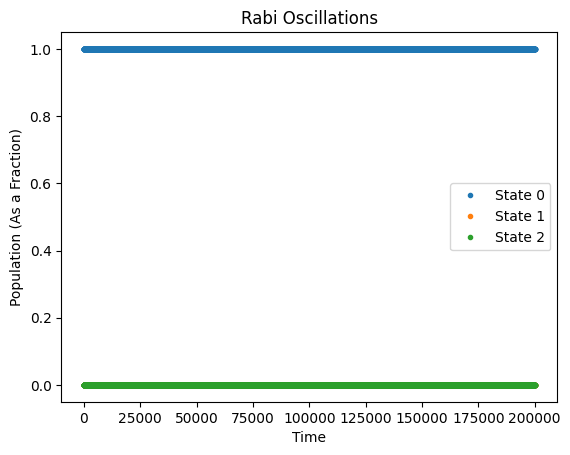

1.8735647
3.7294683


In [137]:
# Rabi Oscillations plot

number_of_states = 3
eigenvalues, eigenvectors = rabilondon.eigenvalues, rabilondon.eigenvectors
populations = [[] for _ in range(number_of_states)]
for i in range(len(output)):
    psi = output[i]
    psi /= jnp.linalg.norm(psi)

    for j in range(number_of_states):
        p_j = jnp.abs(jnp.vdot(eigenvectors[:,j], psi))**2
        populations[j].append(p_j)

for j in range(number_of_states):
    plt.plot(t_grid,populations[j],".",label=f"State {j}")
plt.ylabel("Population (As a Fraction)")
plt.xlabel("Time")
plt.title("Rabi Oscillations")
plt.legend()
plt.show()
print(eigenvalues[1]-eigenvalues[0])
print(eigenvalues[2]-eigenvalues[0])